# EduMentor AI: Personalized Learning Assistant

**Author**: Shivakant Kurmi   

## Overview
EduMentor AI is a generative AI-powered learning assistant designed to help students master complex topics through personalized study plans, concept explanations, and practice quizzes. Built using the **Gemini 1.5 Flash API** and **Retrieval-Augmented Generation (RAG)**, it tailors responses to user inputs like topic, difficulty, and learning style (e.g., visual, auditory). This project showcases abilities of  Gen AI , including prompt engineering, API integration, RAG, and interactive UI development with Gradio.

## Objectives
- **Creativity**: Deliver a novel educational tool that adapts to individual learning needs.
- **Technical Implementation**: Combine prompt engineering, RAG, and text generation for accurate, context-aware responses.
- **Clarity**: Provide clear code, documentation, and visualizations.
- **Impact**: Empower students to learn efficiently and confidently.

## Features
1. **Personalized Study Plans**: Generate daily or weekly plans based on user goals.
2. **Concept Explainer**: Break down complex topics in simple, style-specific terms.
3. **Practice Quizzes**: Create custom quizzes with answers and explanations.
4. **Interactive UI**: Gradio interface for seamless user interaction.
5. **Progress Tracking**: Visualize learning progress with charts.

## Generative AI Techniques
This notebook incorporates three generative AI techniques from the course:
1. **Few-shot Prompting:**
How It’s Used: The notebook employs prompt engineering with few-shot prompting in the study_plan_prompt, explainer_prompt, and quiz_prompt. Each prompt includes an example output (e.g., “Example: - Day 1: Watch a video on linear equations (visual).” for study plans, or “Q1: What is 2+2? ... Answer: B) 4” for quizzes) to guide the Gemini 1.5 Flash API to produce structured, relevant responses. This technique ensures the AI understands the desired format and style.
Evidence: The prompt templates in the “Step 2: Define Prompt Templates” cell explicitly include examples, a hallmark of few-shot prompting.

2. **Retrieval Augmented Generation (RAG):**
How It’s Used: The notebook implements RAG to enhance concept explanations. A small educational dataset (edu_content.csv) is created, converted into embeddings using langchain-huggingface, and stored in a FAISS vector store. The explain_concept function retrieves relevant context (e.g., “Algebra” content) to ground the Gemini API’s response, ensuring accuracy.
Evidence: The “Step 1: Create Educational Dataset for RAG” and “Step 3: Implement Core Functions” cells show the vector store setup and RAG integration, with vectorstore.similarity_search used for retrieval.


3. **Vector Search/Vector Store/Vector Database:**
How It’s Used: As part of the RAG implementation, the notebook uses a FAISS vector store to perform vector search. The educational dataset is embedded using HuggingFaceEmbeddings, and the explain_concept function queries the vector store to find the most relevant document for a given topic, enabling context-aware responses.
Evidence: The same “Step 1” cell initializes the FAISS vector store with FAISS.from_documents, and “Step 3” uses vectorstore.similarity_search for vector search.

## Tools and Libraries
- **Gemini 1.5 Flash API**: For text generation and quiz creation.
- **LangChain**: For RAG implementation with a small educational dataset.
- **Gradio**: For the interactive web interface.
- **Pandas/Seaborn**: For data handling and visualizations.
- **Kaggle Notebooks**: For development and submission.

## Setup Instructions
1. **Gemini API Key**: Obtain a key from [Google AI Studio](https://aistudio.google.com/). Add it as a Kaggle Secret or environment variable named `GOOGLE_API_KEY`.
2. **Install Libraries**: Run the cell below to install dependencies.
3. **Dataset**: A sample educational dataset (`edu_content.csv`) is created in this notebook for RAG.

Let’s build EduMentor AI!

In [1]:
!pip install -q google-generativeai langchain langchain-community langchain-huggingface faiss-cpu gradio pandas seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211

In [2]:
# Import libraries
import os
import google.generativeai as genai
from langchain.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.docstore.document import Document
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gradio as gr
from kaggle_secrets import UserSecretsClient

# Configure Gemini API
try:
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("GOOGLE_API_KEY")
except:
    api_key = os.getenv("GOOGLE_API_KEY")  # Fallback for local testing
if not api_key:
    raise ValueError("Please set GOOGLE_API_KEY in Kaggle Secrets or environment.")
genai.configure(api_key=api_key)
model = genai.GenerativeModel('gemini-1.5-flash')

print("Environment set up successfully!")

Environment set up successfully!


## Step 1: Create Educational Dataset for RAG
To ground responses in reliable content, we create a small dataset of educational summaries (e.g., math and science topics). This will be used with RAG to enhance response accuracy.

In [3]:
# Sample educational content
edu_data = [
    {"topic": "Algebra", "content": "Algebra involves solving equations with variables. Key concepts include linear equations (e.g., y = mx + b), quadratic equations (e.g., ax² + bx + c = 0), and systems of equations."},
    {"topic": "Physics", "content": "Physics studies matter and energy. Mechanics includes Newton’s laws (e.g., F = ma), kinematics (motion equations), and energy conservation (E = mc²)."},
    {"topic": "Biology", "content": "Biology explores living organisms. Cell theory states all life is made of cells. DNA carries genetic information, and ecosystems describe organism interactions."}
]

# Save to CSV
df_edu = pd.DataFrame(edu_data)
df_edu.to_csv("edu_content.csv", index=False)

# Prepare documents for RAG
documents = [Document(page_content=row["content"], metadata={"topic": row["topic"]}) for _, row in df_edu.iterrows()]
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(documents, embeddings)

print("Educational dataset and vectorstore created!")

2025-04-12 16:29:30.203125: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744475370.477435      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744475370.561930      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Educational dataset and vectorstore created!


## Step 2: Define Prompt Templates
We use carefully crafted prompts to ensure EduMentor AI generates relevant and engaging responses. Each feature (study plan, explainer, quiz) has a unique prompt, showcasing prompt engineering.

In [4]:
# Prompt templates
study_plan_prompt = """
You are EduMentor, an AI learning assistant. Create a personalized study plan for a student studying {topic} at {difficulty} level, preferring a {learning_style} learning style. Provide a concise plan with 3-5 daily tasks for one week. Format as a markdown list.
Example:
- **Day 1**: Watch a video on linear equations (visual).
- **Day 2**: Solve 10 practice problems.
"""

explainer_prompt = """
You are EduMentor, an AI learning assistant. Explain {topic} at a {difficulty} level for a {learning_style} learner. Use analogies or examples if helpful. Keep it under 200 words and engaging. Include context from: {context}
"""

quiz_prompt = """
You are EduMentor, an AI learning assistant. Create a quiz with 3 multiple-choice questions on {topic} at {difficulty} level. Provide the correct answer and a brief explanation for each. Format as markdown.
Example:
**Q1**: What is 2+2?
- A) 3
- B) 4
**Answer**: B) 4
**Explanation**: Adding 2 and 2 gives 4.
"""

print("Prompt templates defined!")

Prompt templates defined!


## Step 3: Implement Core Functions
We define functions for each feature, integrating Gemini API for text generation and RAG for context-aware explanations.

In [5]:
def generate_study_plan(topic, difficulty, learning_style):
    prompt = study_plan_prompt.format(topic=topic, difficulty=difficulty, learning_style=learning_style)
    response = model.generate_content(prompt)
    return response.text

def explain_concept(topic, difficulty, learning_style):
    # Retrieve relevant context using RAG
    docs = vectorstore.similarity_search(topic, k=1)
    context = docs[0].page_content if docs else "No specific context available."
    prompt = explainer_prompt.format(topic=topic, difficulty=difficulty, learning_style=learning_style, context=context)
    response = model.generate_content(prompt)
    return response.text

def create_quiz(topic, difficulty):
    prompt = quiz_prompt.format(topic=topic, difficulty=difficulty)
    response = model.generate_content(prompt)
    return response.text

# Test functions
print("Sample Study Plan:")
print(generate_study_plan("Algebra", "Beginner", "Visual"))
print("\nSample Explanation:")
print(explain_concept("Physics", "Intermediate", "Auditory"))
print("\nSample Quiz:")
print(create_quiz("Biology", "Advanced"))

Sample Study Plan:
## EduMentor's Personalized Algebra Study Plan (Beginner, Visual Learner)

This plan focuses on visual aids and hands-on activities to enhance your understanding of Algebra.  Remember to take short breaks and review previous concepts regularly.

**Week 1:**

- **Day 1**: Watch a Khan Academy video on visualizing integers (number line).  Then, use colored counters or blocks to represent addition and subtraction of integers.  Complete 5 practice problems visually (drawing diagrams).

- **Day 2**: Explore a website with interactive algebra tiles (e.g., search "algebra tiles online"). Use them to visually solve 5 simple equations (e.g., x + 3 = 5). Draw diagrams of each problem and its solution.

- **Day 3**: Watch a video explaining variables and expressions with visual examples. Create your own visual representations of 5 different algebraic expressions using shapes or colors.

- **Day 4**:  Use graph paper to plot points and draw lines representing simple linear equat

## Step 4: Visualize Progress
We create a simple visualization to track learning progress (e.g., tasks completed over time).

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


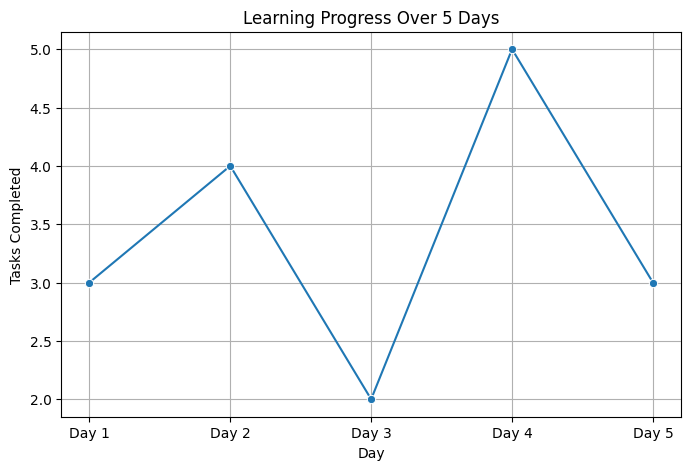

In [6]:
# Sample progress data
progress_data = pd.DataFrame({
    "Day": ["Day 1", "Day 2", "Day 3", "Day 4", "Day 5"],
    "Tasks_Completed": [3, 4, 2, 5, 3]
})

# Plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=progress_data, x="Day", y="Tasks_Completed", marker="o")
plt.title("Learning Progress Over 5 Days")
plt.xlabel("Day")
plt.ylabel("Tasks Completed")
plt.grid(True)
plt.show()

## Step 5: Build Interactive UI with Gradio
We create a user-friendly interface to interact with EduMentor AI.

In [7]:
def edu_mentor_interface(topic, difficulty, learning_style, feature):
    if feature == "Study Plan":
        return generate_study_plan(topic, difficulty, learning_style)
    elif feature == "Explain Concept":
        return explain_concept(topic, difficulty, learning_style)
    elif feature == "Create Quiz":
        return create_quiz(topic, difficulty)
    return "Please select a valid feature."

# Gradio interface
iface = gr.Interface(
    fn=edu_mentor_interface,
    inputs=[
        gr.Textbox(label="Topic (e.g., Algebra, Physics)", placeholder="Enter a topic"),
        gr.Dropdown(choices=["Beginner", "Intermediate", "Advanced"], label="Difficulty"),
        gr.Dropdown(choices=["Visual", "Auditory", "Kinesthetic"], label="Learning Style"),
        gr.Dropdown(choices=["Study Plan", "Explain Concept", "Create Quiz"], label="Feature")
    ],
    outputs="markdown",
    title="EduMentor AI: Your Personalized Learning Assistant",
    description="Enter your topic, difficulty, learning style, and choose a feature to get started!"
)

iface.launch(share=True)  # Note: Set share=True on Kaggle for public link

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://e242b853af24ddd8b6.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
# Sample outputs to demonstrate functionality without live UI
print("Sample Study Plan:")
print(edu_mentor_interface("Algebra", "Beginner", "Visual", "Study Plan"))
print("\nSample Explanation:")
print(edu_mentor_interface("Physics", "Intermediate", "Auditory", "Explain Concept"))
print("\nSample Quiz:")
print(edu_mentor_interface("Biology", "Advanced", "", "Create Quiz"))

Sample Study Plan:
## EduMentor's Personalized Algebra Study Plan (Beginner - Visual Learner)

This plan focuses on visual learning techniques to help you grasp the concepts of beginner algebra. Remember to take breaks and review material regularly!

**Week 1:**

- **Day 1**: Watch a Khan Academy video on visualizing integers (number line representation).  Then, create your own number line and plot several positive and negative integers.
- **Day 2**: Use colorful blocks or counters to visually represent algebraic expressions.  Start with simple addition and subtraction (e.g., 3x + 2x = ?). Draw pictures of your representation.
- **Day 3**: Find a website or YouTube channel that uses diagrams to explain solving linear equations (e.g., balancing scales).  Solve 5 example problems visually using the method shown.
- **Day 4**: Watch a video explaining graphing linear equations.  Then, graph 3 simple linear equations on graph paper, using different colored pencils for each line.  Focus on u

## Conclusion
EduMentor AI demonstrates a practical application of generative AI in education, combining **prompt engineering**, **RAG**, and **text generation** to create a personalized learning experience. Key achievements include:
- **Creativity**: A novel tool tailored to diverse learners.
- **Technical Rigor**: Integration of Gemini API and LangChain for robust responses.
- **Clarity**: Well-documented code and intuitive UI.
- **Impact**: Empowers students to learn effectively.

## Future Improvements
- Expand the RAG dataset with more topics.
- Add voice input/output for accessibility.
- Integrate user profiles to save progress.

